本次实验通过特征提取、特征转换、特征选择三个过程介绍数据预处理方法，特征提取将原始数据转换为适合建模的特征，特征转换将数据进行变换以提高算法的准确性，特征选择用来删除无用的特征

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

终端运行：  
wget https://labfile.oss.aliyuncs.com/courses/1283/renthop_train.json.gz -OutFile renthop_train.json.gz  

gunzip renthop_train.json.gz

In [3]:
df = pd.read_json('renthop_train.json')
df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


## 特征提取-文本处理 ##

在实践中，很少有数据是以矩阵形式保存、可以直接使用的，这就是为什么需要对数据进行特征提取。首先看看在一些常见的数据类型中特征提取是如何进行的。

* 文本数据  
文本的处理方法非常多，本次实验介绍最流行的一种处理过程：

- 在处理文本之前，必须对文本进行切分词（tokenzie）操作，也就是将文本切分为单元（token）。在最简单的情形下，一个 token 就是一个单词。但直接按单词切分可能会损失一些信息，比如「Santa Barbara」应该是一个整体，却被切分为 2 个 token。现成的分词器（tokenizer）会考虑语言的特性，但也会出错，特别是当你处理特定来源的文本时（报纸、俚语、误拼、笔误）。  
- 接下来需要正则化数据。对文本而言，这涉及词干提取（stemming）和词形还原（lemmatization）方法。这两个方法是词形规范化的两类重要方式，都能够达到有效归并词形的目的，二者既有联系也有区别。两者的区别可以参考《Introduction to Information Retrieval》一书的  Stemming and lemmatization 一节。  
- 当文档被转换为单词序列之后，就可以用向量表示它。最简单的方法是词袋（Bag of Words）模型：创建一个长度等于字典的向量，计算每个单词出现在文本中的次数，然后将次数放入向量对应的位置中。  
  
下面用代码来表述词袋模型。

In [4]:
import numpy as np
import pandas as pd
texts = ['i have a cat',
         'you have a dog',
         'you and i have a cat and a dog']

vocabulary = list(enumerate(set([word for sentence
                                 in texts for word in sentence.split()])))
print('Vocabulary:', vocabulary)


def vectorize(text):
    vector = np.zeros(len(vocabulary))
    for i, word in vocabulary:
        num = 0
        for w in text:
            if w == word:
                num += 1
        if num:
            vector[i] = num
    return vector


print('Vectors:')
for sentence in texts:
    print(vectorize(sentence.split()))

Vocabulary: [(0, 'a'), (1, 'you'), (2, 'have'), (3, 'dog'), (4, 'and'), (5, 'i'), (6, 'cat')]
Vectors:
[1. 0. 1. 0. 0. 1. 1.]
[1. 1. 1. 1. 0. 0. 0.]
[2. 1. 1. 1. 2. 1. 1.]


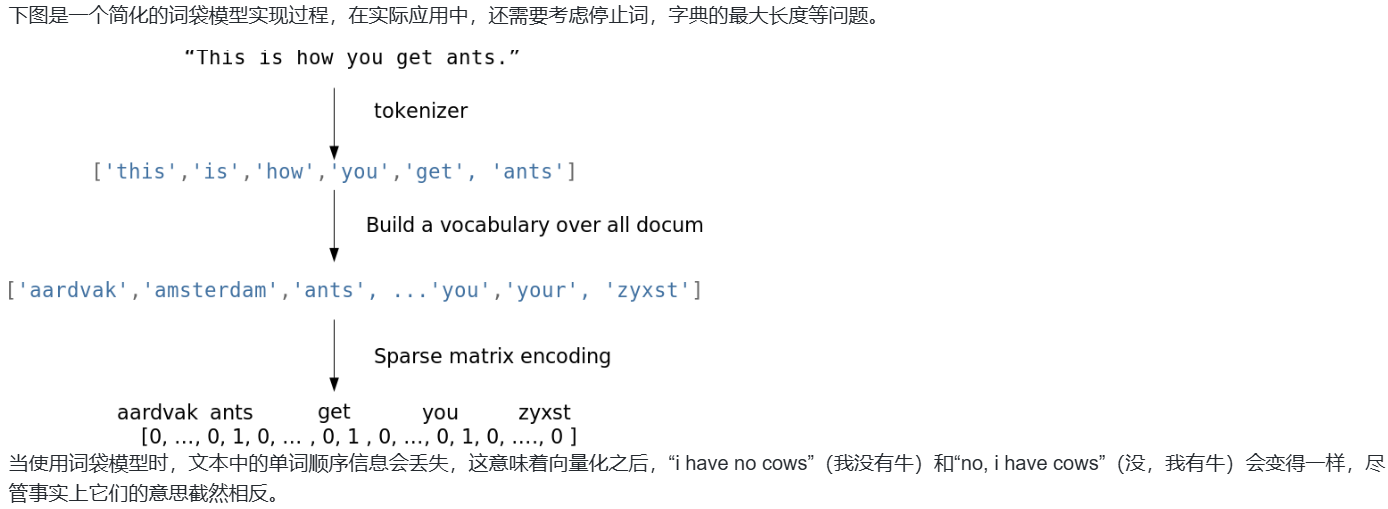

In [5]:
# 为了避免这个问题，可以转而使用 N-Gram 模型。下面载入相关库，建立 N-Gram 模型
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer(ngram_range=(1, 1))
vect.fit_transform(['no i have cows', 'i have no cows']).toarray()

array([[1, 1, 1],
       [1, 1, 1]], dtype=int64)

In [6]:
vect.vocabulary_

{'no': 2, 'have': 1, 'cows': 0}

In [ ]:
# 改变参数
vect = CountVectorizer(ngram_range=(1, 2)) #最小连续词数，最大连续词数
vect.fit_transform(['no i have cows', 'i have no cows']).toarray()

array([[1, 1, 1, 0, 1, 0, 1],
       [1, 1, 0, 1, 1, 1, 0]], dtype=int64)

In [8]:
vect.vocabulary_

{'no': 4,
 'have': 1,
 'cows': 0,
 'no have': 6,
 'have cows': 2,
 'have no': 3,
 'no cows': 5}

除了基于单词生成 N-Gram 模型，在某些情形下，可以基于字符生成 N-Gram 模型，以考虑相关单词的相似性或笔误，下面基于字符生成 N-Gram 模型，并查看它们之间的欧氏距离

In [ ]:
from scipy.spatial.distance import euclidean
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer(ngram_range=(3, 3), analyzer='char_wb') # char_word boundary，在单词边界内提取字符三元组

n1, n2, n3, n4 = vect.fit_transform(
    ['andersen', 'petersen', 'petrov', 'smith']).toarray()

euclidean(n1, n2), euclidean(n2, n3), euclidean(n3, n4)

(2.8284271247461903, 3.1622776601683795, 3.3166247903554)

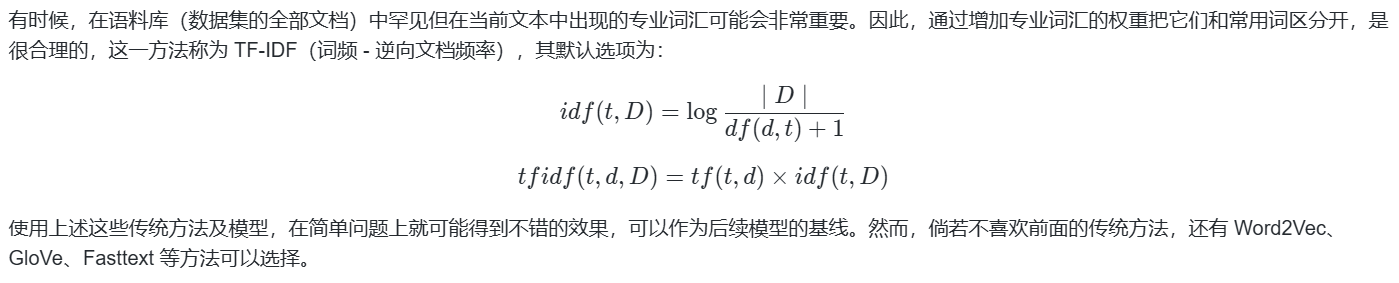

Word2Vec 是词嵌入算法的一个特殊情形。使用 Word2Vec 和类似的模型，不仅可以向量化高维空间（通常是成百上千维的空间）中的单词，还能比较它们的语义相似度  
  
  值得注意的是，Word2Vec 模型并不理解单词的意思，只是尝试将用于相同的上下文的单词向量放在相近的位置。这样的模型需要在非常大的数据集上训练，使向量坐标能够捕捉语义

## 特征提取-图像数据 ##

处理图像既简单又复杂。简单是因为现在我们可以直接使用某个流行的预训练网络，而不用思考太多；复杂是因为，如果深入图像领域，那么就需要考虑非常多的细节问题。

在 GPU 不够强的年代，图像的特征提取本身是一个非常复杂的领域。我们需要对较低的层进行提取，检测角点、区域边界、色彩分布统计等。如果你对这些经典方法感兴趣，可以看下 skimage 和 SimpleCV 这两个库。

现在，和图像相关的问题，常常可以直接使用卷积神经网络来完成。你不需要从头设计网络架构，从头训练网络，下载一个当前最先进的预训练网络及其权重，“分离”网络的最后一个全连接层，增加针对特定任务的新层，接着在新数据上训练网络即可。这一让预训练网络适应特定任务的过程被称为微调（fine-tuning）。

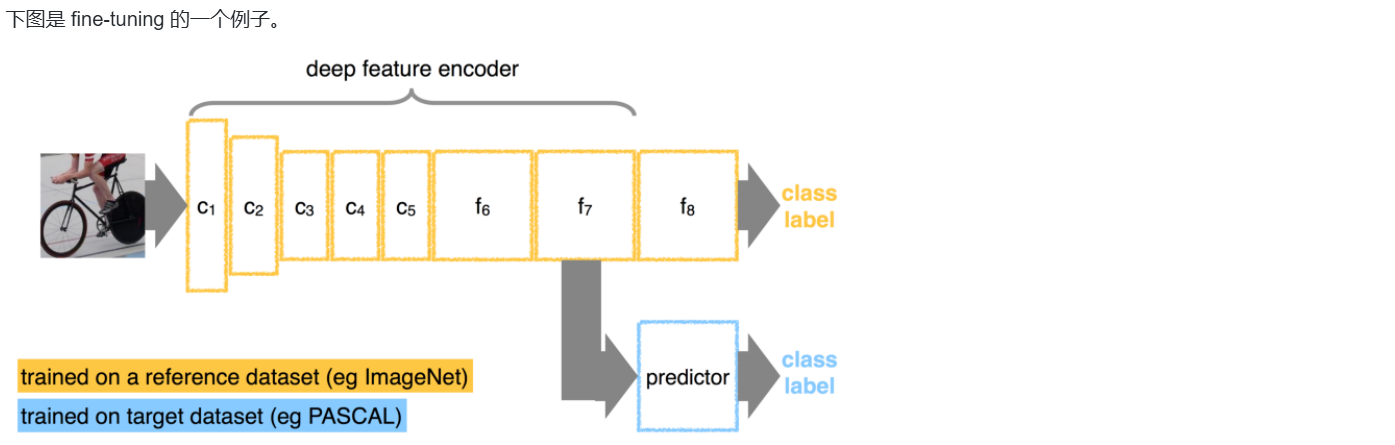

如果任务仅仅是对图像进行向量化（抽取图像的特征），那么只需移除最后一层，使用前一层的输出即可，下面通过调用 PyTorch 中的预训练网络进行图像特征抽取

In [10]:
import torch
import torchvision.transforms as T
import torchvision.models as models
from scipy import datasets
from PIL import Image
import numpy as np

In [11]:
# 使用 ImageNet 预训练权重
weights = models.ResNet18_Weights.IMAGENET1K_V1
base_model = models.resnet18(weights=weights)
# 截断：移除全连接层
resnet = torch.nn.Sequential(*list(base_model.children())[:-1])
print(resnet)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

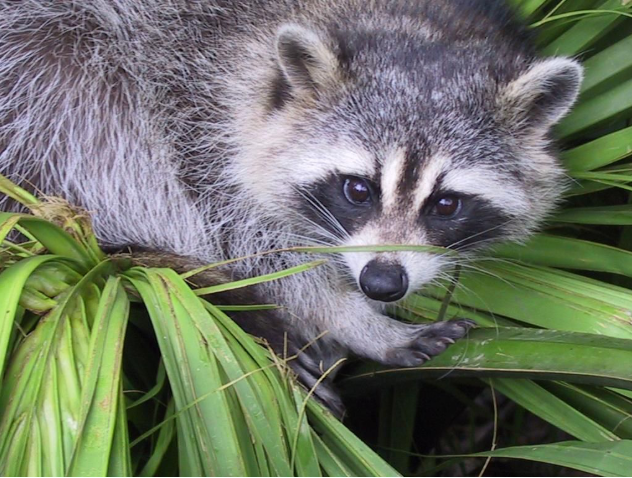

In [12]:
img = Image.open('face.png').convert('RGB')  # 作为 RGB 格式来读取，去除 PNG 的 Alpha 层
img

In [13]:
img.size

(632, 478)

通过张量化，尺寸放缩与标准化适配网络模型的输入格式，其输入格式为张量形状（batch_size, n_channels, height, width）

In [14]:
transform = T.Compose([
    T.ToTensor(),  # 张量化
    T.Resize((224, 224)),  # 尺寸调整
    T.Normalize(mean=weights.transforms().mean, std=weights.transforms().std)  # # 与 ImageNet 预训练相匹配的标准化
])

x = transform(img).unsqueeze(0)  # (1, 3, 224, 224)

with torch.no_grad():
    features = resnet(x)  

features_np = features.cpu().numpy()
features_np.shape

(1, 512, 1, 1)

如果想识别图像上的文字，无需使用复杂的神经网络，使用 pytesseract 库即可完成。首先载入相关库

In [16]:
import pytesseract
from PIL import Image
import requests
from io import BytesIO

In [24]:
img = Image.open('text2.png')
img.show()
#如果是 Windows，需要指定 tesseract 路径：
pytesseract.pytesseract.tesseract_cmd = r"D:\App\Tesseract\tesseract.exe"
pytesseract.image_to_string(img)

'USERS\n\nstring | _id SCHEID\n\nstring | _openid ‘tS OpeniD\n\nDate | createdAt | 3288)\n\nstring | name ste\n\nstring | phone Fas\n\nstring | role Be\n\nhas has\nDEAF_INFO DOCTOR_INFO\n\nstring | _id SZHID string | _id SZHID\nstring | _openid fZOpeniD string | _openid f(ZOpeniD\nstring | allergy wae string | bio BERT\nstring | bloodType me Date | createdAt EBT ial\nDate | createdAt ANZA ia) string | department BAS\nstring | idCard SHES string | licenseNumber | HAMIFAIES\nstring | majorDisease | BARAL string | phone Es\nstring | phone Fils string | professionalTitle | BR#R\n\n'

## 特征转换 ##

对有些算法而言，特征转换是关键，而对另一些算法而言，该转换则毫无帮助。不是所有人都有能力或者愿意去进行特征转换，这是为什么决策树及其变体（随机森林、梯度提升）变得更加流行，因为它们在异常分布上的鲁棒性很好

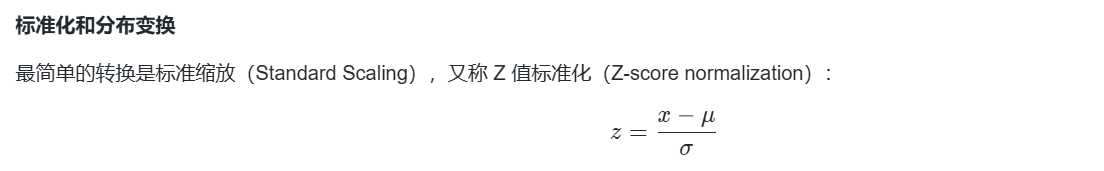

注意，严格意义上说，标准缩放并不生成正态分布，下面验证这一结论，首先载入相关库

In [25]:
from sklearn.preprocessing import StandardScaler
from scipy.stats import beta
from scipy.stats import shapiro
import numpy as np

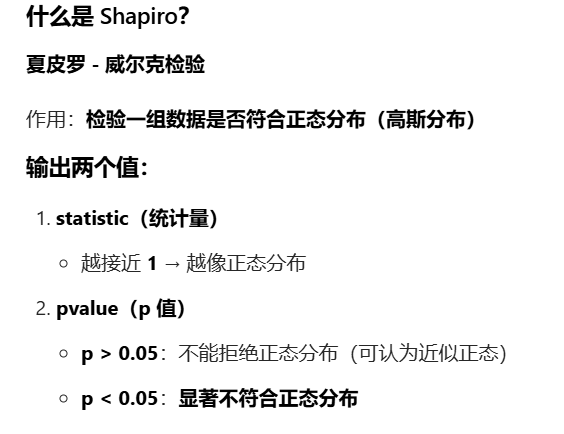

In [26]:
# 使用夏皮罗 - 威尔克检验（Shapiro–Wilk test）查看数据是否符合正态分布，首先输出原数据的检测统计量和假设检验所得的 p 值
data = beta(1, 10).rvs(1000).reshape(-1, 1)
shapiro(data)

ShapiroResult(statistic=0.8726079823432543, pvalue=8.707355619566495e-28)

In [28]:
# 然后输出经标准缩放处理后数据的检测统计量和假设检验所得的 p 值
shapiro(StandardScaler().fit_transform(data)) 
# 标准化不会把非正态分布变成正态分布，标准化只是缩放数据范围，不会改变数据的分布形状

ShapiroResult(statistic=0.8726079823432542, pvalue=8.707355619566495e-28)

夏皮罗 - 威尔克检验计算所得的 p 值说明原数据和经标准缩放处理后的数据都不符合正态分布。

不过，某种程度上而言，标准缩放能为离散值提供一些帮助。下面使用 StandarScaler() 方法对离散值进行标准缩放

In [29]:
data = np.array([1, 1, 0, -1, 2, 1, 2, 3, -2, 4, 100]
                ).reshape(-1, 1).astype(np.float64)
StandardScaler().fit_transform(data)

array([[-0.31922662],
       [-0.31922662],
       [-0.35434155],
       [-0.38945648],
       [-0.28411169],
       [-0.31922662],
       [-0.28411169],
       [-0.24899676],
       [-0.42457141],
       [-0.21388184],
       [ 3.15715128]])

In [30]:
(data - data.mean()) / data.std()

array([[-0.31922662],
       [-0.31922662],
       [-0.35434155],
       [-0.38945648],
       [-0.28411169],
       [-0.31922662],
       [-0.28411169],
       [-0.24899676],
       [-0.42457141],
       [-0.21388184],
       [ 3.15715128]])

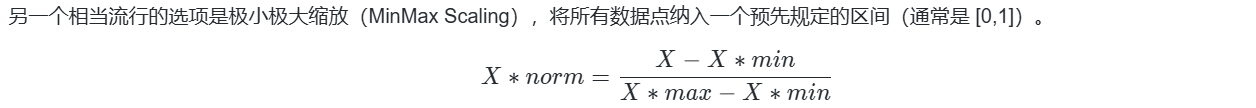

下面用 MinMaxScaler() 方法进行极小极大缩放

In [31]:
from sklearn.preprocessing import MinMaxScaler

MinMaxScaler().fit_transform(data)

array([[0.02941176],
       [0.02941176],
       [0.01960784],
       [0.00980392],
       [0.03921569],
       [0.02941176],
       [0.03921569],
       [0.04901961],
       [0.        ],
       [0.05882353],
       [1.        ]])

In [32]:
(data - data.min()) / (data.max() - data.min())

array([[0.02941176],
       [0.02941176],
       [0.01960784],
       [0.00980392],
       [0.03921569],
       [0.02941176],
       [0.03921569],
       [0.04901961],
       [0.        ],
       [0.05882353],
       [1.        ]])

标准缩放和极小极大缩放的应用类似，常常可以互相替换。然而，如果算法涉及计算数据点或向量之间的距离，默认的选项是标准缩放。而在可视化时，极小极大缩放很有用，因为它可以将特征纳入 [0,255] 区间。

如果某些数据并非正态分布，但可以由  对数正态分布 刻画，那么这些数据很容易就能转换为正态分布，下面生成可以用对数正态分布来刻画的数据，并查看其是否符合正态分布

In [33]:
from scipy.stats import lognorm

data = lognorm(s=1).rvs(1000)
shapiro(data)

ShapiroResult(statistic=0.4210605426605972, pvalue=1.1861368334125915e-48)

上面结果表明生成的原数据不符合正态分布。下面将它进行转换，查看转换后的数据是否符合正态分布

In [34]:
shapiro(np.log(data))

ShapiroResult(statistic=0.9981263420136006, pvalue=0.33964184673671205)

上述结果表明，转换后的数据符合正态分布。

对数正态分布适用于描述薪水、安保费用、城区人口、网络文章评论等信息。然而，底层分布不一定非得是对数正态分布才能应用这一过程，它可以被应用于任何右重尾的分布。此外，还可以尝试使用其他类似的转换，这类转换的例子包括 Box-Cox 转换（对数转换是 Box-Cox 转换的一个特例）和 Yeo-Johnson 转换（将应用范围扩展至负数）。此外，也可以尝试在特征上加上一个常量：np.log (x + const)